### PHASE 1 — WIND SPEED: STATISTICAL PROPERTIES
**Dataset B — ERA5 Reanalysis, Nordfriesland 100 m, 2015–2024**

Based on: Šaltytė Benth & Benth (2009), Tuller & Brett (1984), Garcia et al. (1998)

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from scipy.special import gamma
from scipy.optimize import minimize_scalar
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings
warnings.filterwarnings("ignore")

# ── CONFIGURATION ──────────────────────────────────────────────────────────
DATA_PATH       = "../../data/germany_wind.csv"
SKIP_ROWS       = 2          # ERA5 CSV: 2 metadata header rows before column names
DATE_COL        = "time"
WIND_COL        = "wind_speed_100m (m/s)"   # primary: 100 m hub-height
WIND_COL_10     = "wind_speed_10m (m/s)"    # kept for validation only
FIG_PATH        = "../../reference_tex/Plots/"
N_HARMONICS     = 2   # Fourier harmonics for seasonal mean
N_VAR_HARMONICS = 2   # Fourier harmonics for seasonal variance

# ── 1. LOAD DATA ────────────────────────────────────────────────────────────
df_raw = pd.read_csv(DATA_PATH, skiprows=SKIP_ROWS, parse_dates=[DATE_COL])
df_raw = df_raw.sort_values(DATE_COL).reset_index(drop=True)

print(f"Loaded {len(df_raw)} rows from '{DATA_PATH}'")
print(f"Date range : {df_raw[DATE_COL].min()} → {df_raw[DATE_COL].max()}")
print(f"Columns    : {df_raw.columns.tolist()}")
print(f"Nulls (100m): {df_raw[WIND_COL].isnull().sum()}")

# ── Aggregate hourly → daily mean ──────────────────────────────────────────
df_raw["_date"] = df_raw[DATE_COL].dt.date
df_daily = df_raw.groupby("_date")[WIND_COL].mean().reset_index()
df_daily.columns = ["date", "wind_speed"]
df_daily["date"] = pd.to_datetime(df_daily["date"])

W     = df_daily["wind_speed"].values
dates = df_daily["date"].values
mask  = ~np.isnan(W)
W, dates = W[mask], dates[mask]
n = len(W)

wind_daily = df_daily.set_index("date")

print(f"\nDaily observations : {n}")
print(f"Daily date range   : {pd.Timestamp(dates[0]).date()} → {pd.Timestamp(dates[-1]).date()}")
print(f"Mean wind (100 m)  : {W.mean():.4f} m/s")
print(f"Min / Max          : {W.min():.4f} / {W.max():.4f} m/s")

Loaded 87672 rows from '../../data/germany_wind.csv'
Date range : 2015-01-01 00:00:00 → 2024-12-31 23:00:00
Columns    : ['time', 'wind_speed_10m (m/s)', 'wind_speed_100m (m/s)', 'wind_direction_100m (°)']
Nulls (100m): 0

Daily observations : 3653
Daily date range   : 2015-01-01 → 2024-12-31
Mean wind (100 m)  : 8.0682 m/s
Min / Max          : 1.3825 / 20.2575 m/s


In [28]:
mean_W    = np.mean(W)
median_W  = np.median(W)
std_W     = np.std(W, ddof=1)
var_W     = np.var(W, ddof=1)
min_W     = np.min(W)
max_W     = np.max(W)
skew_W    = stats.skew(W)
kurt_W    = stats.kurtosis(W, fisher=True)
jb_stat, jb_pval = stats.jarque_bera(W)

print("\n" + "="*58)
print("  DESCRIPTIVE STATISTICS — RAW WIND SPEED (100 m, daily)")
print("="*58)
print(f"  n               : {n}")
print(f"  Mean            : {mean_W:.4f} m/s")
print(f"  Median          : {median_W:.4f} m/s")
print(f"  Std deviation   : {std_W:.4f} m/s")
print(f"  Variance        : {var_W:.4f} m²/s²")
print(f"  Min             : {min_W:.4f} m/s")
print(f"  Max             : {max_W:.4f} m/s")
print(f"  Skewness        : {skew_W:.4f}   (normal = 0)")
print(f"  Excess Kurtosis : {kurt_W:.4f}  (normal = 0)")
print(f"  JB statistic    : {jb_stat:.4f}")
print(f"  JB p-value      : {jb_pval:.6f}  (H0: normal)")
print("="*58)
print(f"  Mean > Median   : {mean_W > median_W}  → right skew check")


  DESCRIPTIVE STATISTICS — RAW WIND SPEED (100 m, daily)
  n               : 3653
  Mean            : 8.0682 m/s
  Median          : 7.7600 m/s
  Std deviation   : 3.2361 m/s
  Variance        : 10.4723 m²/s²
  Min             : 1.3825 m/s
  Max             : 20.2575 m/s
  Skewness        : 0.5853   (normal = 0)
  Excess Kurtosis : 0.1113  (normal = 0)
  JB statistic    : 210.4378
  JB p-value      : 0.000000  (H0: normal)
  Mean > Median   : True  → right skew check


## 3. WEIBULL DISTRIBUTION FITTING  (Tuller & Brett 1984; Garcia et al. 1998)

Linearise the Weibull CDF via double-log transform, then OLS:

&nbsp;&nbsp;ln(−ln(1 − F(v))) = k·ln(v) − k·ln(c)

All R² values are computed in **histogram density space** for a commensurable comparison (Garcia et al. 1998).

In [29]:
bins          = np.arange(0, max_W + 1.5, 0.5)
counts, edges = np.histogram(W, bins=bins)
bin_centers   = 0.5 * (edges[:-1] + edges[1:])
cum_prob      = np.cumsum(counts) / n

mask_fit = (cum_prob > 0.001) & (cum_prob < 0.999) & (bin_centers > 0)
v_fit    = bin_centers[mask_fit]
F_fit    = cum_prob[mask_fit]

Y = np.log(-np.log(1 - F_fit))
t = np.log(v_fit)

freq_density = counts[mask_fit] / (n * np.diff(bins)[mask_fit])
ss_tot       = np.sum((freq_density - np.mean(freq_density))**2)

# OLS on Weibull probability paper
slope, intercept, r_value, p_val, se = stats.linregress(t, Y)
k_weib     = slope
c_weib     = np.exp(-intercept / k_weib)
r2_weib_pp = r_value**2
mean_weib  = c_weib * gamma(1 + 1/k_weib)

W_pos = W[W > 0]

# Weibull MLE (scipy)
params_mle    = stats.weibull_min.fit(W_pos, floc=0)
k_mle, c_mle = params_mle[0], params_mle[2]

# Lognormal
m_logn = np.mean(np.log(W_pos))
s_logn = np.std(np.log(W_pos), ddof=1)

# R² in histogram density space
pdf_weib_ols     = stats.weibull_min.pdf(v_fit, k_weib, loc=0, scale=c_weib)
r2_weib_hist     = 1 - np.sum((freq_density - pdf_weib_ols)**2) / ss_tot

pdf_weib_mle     = stats.weibull_min.pdf(v_fit, k_mle, loc=0, scale=c_mle)
r2_weib_mle_hist = 1 - np.sum((freq_density - pdf_weib_mle)**2) / ss_tot

pdf_logn_vals    = stats.lognorm.pdf(v_fit, s=s_logn, scale=np.exp(m_logn))
r2_logn          = 1 - np.sum((freq_density - pdf_logn_vals)**2) / ss_tot

# KS tests
ks_weib_mle, ks_weib_p = stats.kstest(W_pos,
    lambda x: stats.weibull_min.cdf(x, k_mle, loc=0, scale=c_mle))
ks_logn, ks_logn_p     = stats.kstest(W_pos,
    lambda x: stats.lognorm.cdf(x, s=s_logn, scale=np.exp(m_logn)))

print("\n" + "="*58)
print("  WEIBULL FIT (linearised CDF, OLS)")
print("="*58)
print(f"  Shape k                    : {k_weib:.4f}")
print(f"  Scale c                    : {c_weib:.4f} m/s")
print(f"  R² (probability paper)     : {r2_weib_pp:.4f}  — linearisation diagnostic only")
print(f"  Weibull mean (theoretical) : {mean_weib:.4f} m/s  (sample: {mean_W:.4f})")
print(f"\n  MLE check — k: {k_mle:.4f}  c: {c_mle:.4f}")
print(f"\n  LOGNORMAL FIT")
print(f"  m (E[ln v])   : {m_logn:.4f}")
print(f"  s (Std[ln v]) : {s_logn:.4f}")
print("\n" + "="*58)
print("  FAIR DISTRIBUTION COMPARISON (histogram density space)")
print("="*58)
print(f"  {'Model':<26} {'R² (hist)':>10} {'KS stat':>9} {'KS p':>9}")
print(f"  {'-'*54}")
print(f"  {'Weibull (OLS k,c)':<26} {r2_weib_hist:>10.4f} {ks_weib_mle:>9.4f} {ks_weib_p:>9.4f}")
print(f"  {'Weibull (MLE k,c)':<26} {r2_weib_mle_hist:>10.4f} {ks_weib_mle:>9.4f} {ks_weib_p:>9.4f}")
print(f"  {'Lognormal':<26} {r2_logn:>10.4f} {ks_logn:>9.4f} {ks_logn_p:>9.4f}")
print("="*58)
print(f"  Better fit (R²) : {'Weibull (MLE)' if r2_weib_mle_hist >= r2_logn else 'Lognormal'}")
print(f"  Better fit (KS) : {'Weibull (MLE)' if ks_weib_p >= ks_logn_p else 'Lognormal'}")
print(f"\n  NOTE: R²(prob.paper) = {r2_weib_pp:.4f} is a linearisation diagnostic only.")
print(f"  The definitive comparison is AIC/BIC in Cell 5.")


  WEIBULL FIT (linearised CDF, OLS)
  Shape k                    : 2.8889
  Scale c                    : 9.1730 m/s
  R² (probability paper)     : 0.9798  — linearisation diagnostic only
  Weibull mean (theoretical) : 8.1782 m/s  (sample: 8.0682)

  MLE check — k: 2.6704  c: 9.0890

  LOGNORMAL FIT
  m (E[ln v])   : 2.0022
  s (Std[ln v]) : 0.4283

  FAIR DISTRIBUTION COMPARISON (histogram density space)
  Model                       R² (hist)   KS stat      KS p
  ------------------------------------------------------
  Weibull (OLS k,c)              0.9395    0.0242    0.0269
  Weibull (MLE k,c)              0.9630    0.0242    0.0269
  Lognormal                      0.9395    0.0439    0.0000
  Better fit (R²) : Weibull (MLE)
  Better fit (KS) : Weibull (MLE)

  NOTE: R²(prob.paper) = 0.9798 is a linearisation diagnostic only.
  The definitive comparison is AIC/BIC in Cell 5.


## 4. BOX-COX TRANSFORMATION  (Šaltytė Benth & Benth 2009)

W^(λ)(t) = (W(t)^λ − 1) / λ  for λ ≠ 0  |  ln W(t) for λ = 0

λ estimated by maximising the profile log-likelihood under normality. The tractable λ (1/λ ∈ ℤ⁺) is used downstream for closed-form pricing.

In [30]:
def boxcox_transform(x, lam):
    if abs(lam) < 1e-10:
        return np.log(x)
    return (x**lam - 1) / lam

def boxcox_loglik(lam, x):
    x_pos = x[x > 0]
    y     = boxcox_transform(x_pos, lam)
    var_  = np.var(y)
    if var_ <= 0: return np.inf
    return -(-len(y)/2 * np.log(var_) + (lam - 1) * np.sum(np.log(x_pos)))

result     = minimize_scalar(boxcox_loglik, bounds=(-2, 2), method='bounded', args=(W[W > 0],))
lambda_opt = result.x

lambda_candidates = [0.1, 0.2, 0.25, 0.5, 1.0]
lambda_round      = min(lambda_candidates, key=lambda x: abs(x - lambda_opt))

W_bc_opt   = boxcox_transform(W_pos, lambda_opt)
W_bc_round = boxcox_transform(W_pos, lambda_round)

# Post-transformation normality tests
skew_bc_opt = stats.skew(W_bc_opt)
kurt_bc_opt = stats.kurtosis(W_bc_opt, fisher=True)
jb_bc_opt   = stats.jarque_bera(W_bc_opt)
ks_bc_opt   = stats.kstest((W_bc_opt - np.mean(W_bc_opt)) / np.std(W_bc_opt), 'norm')

skew_bc_r   = stats.skew(W_bc_round)
kurt_bc_r   = stats.kurtosis(W_bc_round, fisher=True)
jb_bc_r     = stats.jarque_bera(W_bc_round)
ks_bc_r     = stats.kstest((W_bc_round - np.mean(W_bc_round)) / np.std(W_bc_round), 'norm')

W_log    = np.log(W_pos)
skew_log = stats.skew(W_log)
kurt_log = stats.kurtosis(W_log, fisher=True)
jb_log   = stats.jarque_bera(W_log)

print("\n" + "="*58)
print("  BOX-COX TRANSFORMATION")
print("="*58)
print(f"  Optimal λ (MLE)    : {lambda_opt:.4f}")
print(f"  Rounded (tractable): {lambda_round}  → 1/λ = {1/lambda_round:.1f}")
print(f"  Note: 1/λ must be a positive integer for closed-form pricing")
print(f"\n  --- After transformation (optimal λ = {lambda_opt:.4f})")
print(f"  Skewness       : {skew_bc_opt:.4f}   (target: ~0)")
print(f"  Excess Kurtosis: {kurt_bc_opt:.4f}  (target: ~0)")
print(f"  JB p-value     : {jb_bc_opt[1]:.6f}  (H0: normal, want p > 0.05)")
print(f"  KS p-value     : {ks_bc_opt[1]:.6f}  (H0: normal, want p > 0.05)")
print(f"\n  --- After transformation (rounded λ = {lambda_round})")
print(f"  Skewness       : {skew_bc_r:.4f}   (target: ~0)")
print(f"  Excess Kurtosis: {kurt_bc_r:.4f}  (target: ~0)")
print(f"  JB p-value     : {jb_bc_r[1]:.6f}  (H0: normal, want p > 0.05)")
print(f"  KS p-value     : {ks_bc_r[1]:.6f}  (H0: normal, want p > 0.05)")
print(f"\n  --- Log-transform (λ = 0) for comparison")
print(f"  Skewness       : {skew_log:.4f}")
print(f"  Excess Kurtosis: {kurt_log:.4f}")
print(f"  JB p-value     : {jb_log[1]:.6f}")


  BOX-COX TRANSFORMATION
  Optimal λ (MLE)    : 0.4039
  Rounded (tractable): 0.5  → 1/λ = 2.0
  Note: 1/λ must be a positive integer for closed-form pricing

  --- After transformation (optimal λ = 0.4039)
  Skewness       : -0.0200   (target: ~0)
  Excess Kurtosis: -0.3342  (target: ~0)
  JB p-value     : 0.000180  (H0: normal, want p > 0.05)
  KS p-value     : 0.414529  (H0: normal, want p > 0.05)

  --- After transformation (rounded λ = 0.5)
  Skewness       : 0.0808   (target: ~0)
  Excess Kurtosis: -0.3365  (target: ~0)
  JB p-value     : 0.000025  (H0: normal, want p > 0.05)
  KS p-value     : 0.091070  (H0: normal, want p > 0.05)

  --- Log-transform (λ = 0) for comparison
  Skewness       : -0.4698
  Excess Kurtosis: 0.0612
  JB p-value     : 0.000000


## 5. AIC / BIC — WEIBULL vs LOGNORMAL

AIC = −2·ℓ + 2k  |  BIC = −2·ℓ + k·ln(n)  |  k = 2 for both models. Lower is better.

In [31]:
def aic_bic(loglik, n_params, n_obs):
    aic = -2*loglik + 2*n_params
    bic = -2*loglik + n_params * np.log(n_obs)
    return aic, bic

ll_weib              = np.sum(stats.weibull_min.logpdf(W_pos, k_weib, loc=0, scale=c_weib))
aic_hat, bic_hat     = aic_bic(ll_weib, 2, len(W_pos))

ll_weib_mle              = np.sum(stats.weibull_min.logpdf(W_pos, k_mle, loc=0, scale=c_mle))
aic_hat_mle, bic_hat_mle = aic_bic(ll_weib_mle, 2, len(W_pos))

ll_logn              = np.sum(stats.lognorm.logpdf(W_pos, s=s_logn, scale=np.exp(m_logn)))
aic_logn, bic_logn   = aic_bic(ll_logn, 2, len(W_pos))

print("=" * 58)
print("  AIC / BIC — DISTRIBUTION COMPARISON")
print("=" * 58)
print(f"  {'Model':<25} {'LogLik':>10} {'AIC':>10} {'BIC':>10}")
print(f"  {'-'*52}")
print(f"  {'Weibull (OLS k,c)':<25} {ll_weib:>10.2f} {aic_hat:>10.2f} {bic_hat:>10.2f}")
print(f"  {'Weibull (MLE k,c)':<25} {ll_weib_mle:>10.2f} {aic_hat_mle:>10.2f} {bic_hat_mle:>10.2f}")
print(f"  {'Lognormal':<25} {ll_logn:>10.2f} {aic_logn:>10.2f} {bic_logn:>10.2f}")
print("=" * 58)
print(f"  Best model (AIC): {'Weibull' if aic_hat_mle < aic_logn else 'Lognormal'}")
print(f"  Best model (BIC): {'Weibull' if bic_hat_mle < bic_logn else 'Lognormal'}")
print(f"\n  Weibull MLE: k={k_mle:.4f}  c={c_mle:.4f} m/s")
print(f"  (vs OLS:     k={k_weib:.4f}  c={c_weib:.4f} m/s)")

  AIC / BIC — DISTRIBUTION COMPARISON
  Model                         LogLik        AIC        BIC
  ----------------------------------------------------
  Weibull (OLS k,c)           -9398.02   18800.04   18812.44
  Weibull (MLE k,c)           -9377.13   18758.26   18770.67
  Lognormal                   -9399.55   18803.10   18815.50
  Best model (AIC): Weibull
  Best model (BIC): Weibull

  Weibull MLE: k=2.6704  c=9.0890 m/s
  (vs OLS:     k=2.8889  c=9.1730 m/s)


## 6. SEASONAL MEAN Λ(t) — TRUNCATED FOURIER SERIES  (Šaltytė Benth & Benth 2009)

Λ(t) = a₀ + Σₖ [ aₖ·cos(2πkt/365) + bₖ·sin(2πkt/365) ]  k = 1 … N_HARMONICS

Estimated by OLS on the Box-Cox transformed series W^(λ)(t) with λ = `lambda_round`.

In [32]:
W_bc_full = boxcox_transform(W, lambda_round)
doy       = pd.DatetimeIndex(wind_daily.index).dayofyear.values

def fourier_basis(doy_arr, n_harmonics):
    cols = [np.ones(len(doy_arr))]
    for k in range(1, n_harmonics + 1):
        cols.append(np.cos(2 * np.pi * k * doy_arr / 365))
        cols.append(np.sin(2 * np.pi * k * doy_arr / 365))
    return np.column_stack(cols)

X_fourier  = fourier_basis(doy, N_HARMONICS)
model_mean = sm.OLS(W_bc_full, X_fourier).fit()
Lambda_t   = model_mean.fittedvalues
eps_t      = W_bc_full - Lambda_t

param_names = ['a0'] + [f for k in range(1, N_HARMONICS+1)
                        for f in [f'a{k}(cos)', f'b{k}(sin)']]

print("\n" + "=" * 58)
print("  SEASONAL MEAN Λ(t) — FOURIER FIT (OLS)")
print("=" * 58)
print(f"  Harmonics : {N_HARMONICS} (annual + semi-annual)")
print(f"  R²        : {model_mean.rsquared:.4f}")
print(f"  R² adj    : {model_mean.rsquared_adj:.4f}")
print(f"\n  Estimated coefficients:")
for name, coef, pval in zip(param_names, model_mean.params, model_mean.pvalues):
    sig = "***" if pval < 0.01 else ("**" if pval < 0.05 else ("*" if pval < 0.1 else ""))
    print(f"    {name:<14} {coef:>10.5f}   p={pval:.4f} {sig}")
print(f"\n  Residuals ε(t):")
print(f"    Mean : {eps_t.mean():.6f}  (should be ~0)")
print(f"    Std  : {eps_t.std():.4f}")
lb_eps = acorr_ljungbox(eps_t, lags=10, return_df=True)
print(f"    LBQ p (lag 5) : {lb_eps['lb_pvalue'].iloc[4]:.4f}"
      f"  (autocorrelation expected — AR(4) in Phase 2)")


  SEASONAL MEAN Λ(t) — FOURIER FIT (OLS)
  Harmonics : 2 (annual + semi-annual)
  R²        : 0.1031
  R² adj    : 0.1021

  Estimated coefficients:
    a0                3.56416   p=0.0000 ***
    a1(cos)           0.51005   p=0.0000 ***
    b1(sin)           0.08272   p=0.0011 ***
    a2(cos)           0.04738   p=0.0617 *
    b2(sin)          -0.00443   p=0.8614 

  Residuals ε(t):
    Mean : 0.000000  (should be ~0)
    Std  : 1.0830
    LBQ p (lag 5) : 0.0000  (autocorrelation expected — AR(4) in Phase 2)


## 7. SEASONAL VARIANCE σ²(t) — EMPIRICAL + FOURIER FIT  (Šaltytė Benth & Benth 2009)

1. Group ε(t) by calendar DOY → empirical variance per day  
2. Fit cosine-only Fourier series to the 365 empirical variances  
3. σ²(t) evaluated at each observation's DOY; clipped at 10⁻⁸ for positivity

In [33]:
df_eps         = pd.DataFrame({'eps': eps_t, 'doy': doy}, index=wind_daily.index)
emp_var_series = df_eps.groupby('doy')['eps'].var().dropna()
doy_vals       = emp_var_series.index.values
emp_var_vals   = emp_var_series.values

def fourier_basis_cos(doy_arr, n_harmonics):
    cols = [np.ones(len(doy_arr))]
    for k in range(1, n_harmonics + 1):
        cols.append(np.cos(2 * np.pi * k * doy_arr / 365))
    return np.column_stack(cols)

X_var    = fourier_basis_cos(doy_vals, N_VAR_HARMONICS)
mod_var  = sm.OLS(emp_var_vals, X_var).fit()
sigma2_t = mod_var.predict(fourier_basis_cos(doy, N_VAR_HARMONICS))
sigma2_t = np.maximum(sigma2_t, 1e-8)
sigma_t  = np.sqrt(sigma2_t)

var_param_names = ['c0'] + [f'c{k}(cos)' for k in range(1, N_VAR_HARMONICS+1)]

print("\n" + "=" * 58)
print("  SEASONAL VARIANCE σ²(t) — FOURIER FIT (OLS, cosines)")
print("=" * 58)
print(f"  Harmonics : {N_VAR_HARMONICS}")
print(f"  R²        : {mod_var.rsquared:.4f}")
print(f"  Note: with 10 years of data, ~10 obs/DOY — more stable than Dataset A (4 obs/DOY)")
print(f"\n  Estimated coefficients:")
for name, coef, pval in zip(var_param_names, mod_var.params, mod_var.pvalues):
    sig = "***" if pval < 0.01 else ("**" if pval < 0.05 else ("*" if pval < 0.1 else ""))
    print(f"    {name:<14} {coef:>10.5f}   p={pval:.4f} {sig}")
print(f"\n  σ²(t) range : [{sigma2_t.min():.4f}, {sigma2_t.max():.4f}]")
print(f"  σ(t)  range : [{sigma_t.min():.4f},  {sigma_t.max():.4f}]")


  SEASONAL VARIANCE σ²(t) — FOURIER FIT (OLS, cosines)
  Harmonics : 2
  R²        : 0.1158
  Note: with 10 years of data, ~10 obs/DOY — more stable than Dataset A (4 obs/DOY)

  Estimated coefficients:
    c0                1.16277   p=0.0000 ***
    c1(cos)           0.25933   p=0.0000 ***
    c2(cos)           0.04077   p=0.2855 

  σ²(t) range : [0.9442, 1.4629]
  σ(t)  range : [0.9717,  1.2095]


## 8. STANDARDISED SERIES W̃(t)

W̃(t) = ε(t) / σ(t) = [ W^(λ)(t) − Λ(t) ] / σ(t)

Target: stationary, mean ≈ 0, std ≈ 1, no serial autocorrelation (LBQ), approximately Gaussian.

In [34]:
W_tilde = eps_t / sigma_t

mean_wt          = W_tilde.mean()
std_wt           = W_tilde.std(ddof=1)
skew_wt          = stats.skew(W_tilde)
kurt_wt          = stats.kurtosis(W_tilde, fisher=False)
jb_wt,  jb_wt_p = stats.jarque_bera(W_tilde)
ks_wt,  ks_wt_p = stats.kstest((W_tilde - mean_wt)/std_wt, 'norm')

lb_wt  = acorr_ljungbox(W_tilde,    lags=20, return_df=True)
lb_wt2 = acorr_ljungbox(W_tilde**2, lags=20, return_df=True)

print("\n" + "=" * 58)
print("  FINAL STANDARDISED SERIES W̃(t)")
print("=" * 58)
print(f"  W̃(t) = ε(t) / σ(t)   λ = {lambda_round}")
print(f"\n  Descriptive statistics:")
print(f"    Mean     : {mean_wt:.6f}   (target = 0)")
print(f"    Std      : {std_wt:.4f}   (target = 1)")
print(f"    Skewness : {skew_wt:.4f}   (target ~ 0)")
print(f"    Kurtosis : {kurt_wt:.4f}   (target ~ 3, Pearson)")
print(f"\n  Normality tests:")
print(f"    JB stat  : {jb_wt:.4f}")
print(f"    JB p-val : {jb_wt_p:.4f}   (> 0.05 = normal)")
print(f"    KS p-val : {ks_wt_p:.4f}   (> 0.05 = normal)")
print(f"\n  Serial autocorrelation (LBQ on W̃):")
for lag in [5, 10, 20]:
    p = lb_wt['lb_pvalue'].iloc[lag-1]
    print(f"    Lag {lag:2d}: p = {p:.4f}   {'OK' if p > 0.05 else 'AUTOCORR PRESENT'}")
print(f"\n  Conditional heteroskedasticity (LBQ on W̃²):")
for lag in [5, 10, 20]:
    p = lb_wt2['lb_pvalue'].iloc[lag-1]
    print(f"    Lag {lag:2d}: p = {p:.4f}   {'OK' if p > 0.05 else 'GARCH EFFECTS PRESENT'}")
print(f"\n  INTERPRETATION:")
if jb_wt_p > 0.05:
    print(f"  [PASS] W̃(t) is approximately Gaussian.")
else:
    print(f"  [NOTE] W̃(t) departs from normality — AR(4) residue; Phase 2 will reduce this.")
if lb_wt['lb_pvalue'].iloc[-1] < 0.05:
    print(f"  [EXPECTED] Serial autocorrelation present → AR(4) needed (Phase 2).")
if lb_wt2['lb_pvalue'].iloc[-1] < 0.05:
    print(f"  [EXPECTED] Conditional heteroskedasticity present → GARCH needed (Phase 3).")

W_tilde_series = pd.Series(W_tilde, index=wind_daily.index, name='W_tilde')
print(f"\n  W_tilde_series ready for Phase 2: {len(W_tilde_series)} observations")


  FINAL STANDARDISED SERIES W̃(t)
  W̃(t) = ε(t) / σ(t)   λ = 0.5

  Descriptive statistics:
    Mean     : -0.000029   (target = 0)
    Std      : 1.0050   (target = 1)
    Skewness : -0.0570   (target ~ 0)
    Kurtosis : 2.5779   (target ~ 3, Pearson)

  Normality tests:
    JB stat  : 29.0942
    JB p-val : 0.0000   (> 0.05 = normal)
    KS p-val : 0.2274   (> 0.05 = normal)

  Serial autocorrelation (LBQ on W̃):
    Lag  5: p = 0.0000   AUTOCORR PRESENT
    Lag 10: p = 0.0000   AUTOCORR PRESENT
    Lag 20: p = 0.0000   AUTOCORR PRESENT

  Conditional heteroskedasticity (LBQ on W̃²):
    Lag  5: p = 0.0000   GARCH EFFECTS PRESENT
    Lag 10: p = 0.0000   GARCH EFFECTS PRESENT
    Lag 20: p = 0.0000   GARCH EFFECTS PRESENT

  INTERPRETATION:
  [NOTE] W̃(t) departs from normality — AR(4) residue; Phase 2 will reduce this.
  [EXPECTED] Serial autocorrelation present → AR(4) needed (Phase 2).
  [EXPECTED] Conditional heteroskedasticity present → GARCH needed (Phase 3).

  W_tilde_serie

## 9. WEIBULL AEP BASELINE (100 m hub height)

Dataset B provides wind speed directly at 100 m — no vertical profile correction required. Turbine parameters reflect a modern 3 MW onshore machine representative of the Nordfriesland fleet (Schleswig-Holstein).

In [35]:
MEASUREMENT_HEIGHT_M = 100.0   # ERA5 wind_speed_100m — no correction needed
V_CUTIN   = 3.0     # m/s
V_RATED   = 13.0    # m/s  (3 MW onshore class)
V_CUTOUT  = 25.0    # m/s
P_RATED   = 3000    # kW

v_grid_aep  = np.linspace(0, 35, 3500)
power_curve = np.where(
    (v_grid_aep < V_CUTIN) | (v_grid_aep > V_CUTOUT), 0,
    np.where(v_grid_aep >= V_RATED, P_RATED,
             P_RATED * ((v_grid_aep - V_CUTIN) / (V_RATED - V_CUTIN))**3))

dv       = v_grid_aep[1] - v_grid_aep[0]
prob_bin = stats.weibull_min.pdf(v_grid_aep, k_mle, loc=0, scale=c_mle) * dv

aep_kwh    = np.sum(power_curve * prob_bin) * 8760
aep_gwh    = aep_kwh / 1e6
cap_factor = aep_kwh / (P_RATED * 8760)

p_above_cutin  = 1 - stats.weibull_min.cdf(V_CUTIN,  k_mle, loc=0, scale=c_mle)
p_above_rated  = 1 - stats.weibull_min.cdf(V_RATED,  k_mle, loc=0, scale=c_mle)
p_above_cutout = 1 - stats.weibull_min.cdf(V_CUTOUT, k_mle, loc=0, scale=c_mle)

print("\n" + "=" * 58)
print("  WEIBULL AEP BASELINE (100 m, Nordfriesland)")
print("=" * 58)
print(f"  Weibull params (MLE): k={k_mle:.4f}  c={c_mle:.4f} m/s")
print(f"  Mean wind (100 m)   : {mean_W:.2f} m/s")
print(f"\n  Turbine parameters (3 MW onshore):")
print(f"    Cut-in  : {V_CUTIN} m/s")
print(f"    Rated   : {V_RATED} m/s")
print(f"    Cut-out : {V_CUTOUT} m/s")
print(f"\n  AEP (at 100 m)  : {aep_gwh:.4f} GWh/year")
print(f"  Capacity factor : {cap_factor:.4f}  ({cap_factor*100:.2f}%)")
print(f"\n  Exceedance probabilities:")
print(f"    P(v > cut-in  {V_CUTIN} m/s) : {p_above_cutin:.4f}  ({p_above_cutin*100:.1f}%)")
print(f"    P(v > rated  {V_RATED} m/s) : {p_above_rated:.4f}  ({p_above_rated*100:.1f}%)")
print(f"    P(v > cutout {V_CUTOUT} m/s): {p_above_cutout:.6f}  ({p_above_cutout*100:.3f}%)")


  WEIBULL AEP BASELINE (100 m, Nordfriesland)
  Weibull params (MLE): k=2.6704  c=9.0890 m/s
  Mean wind (100 m)   : 8.07 m/s

  Turbine parameters (3 MW onshore):
    Cut-in  : 3.0 m/s
    Rated   : 13.0 m/s
    Cut-out : 25.0 m/s

  AEP (at 100 m)  : 6.7532 GWh/year
  Capacity factor : 0.2570  (25.70%)

  Exceedance probabilities:
    P(v > cut-in  3.0 m/s) : 0.9495  (95.0%)
    P(v > rated  13.0 m/s) : 0.0742  (7.4%)
    P(v > cutout 25.0 m/s): 0.000000  (0.000%)


## 10. PLOTS — RAW WIND SPEED & DISTRIBUTION

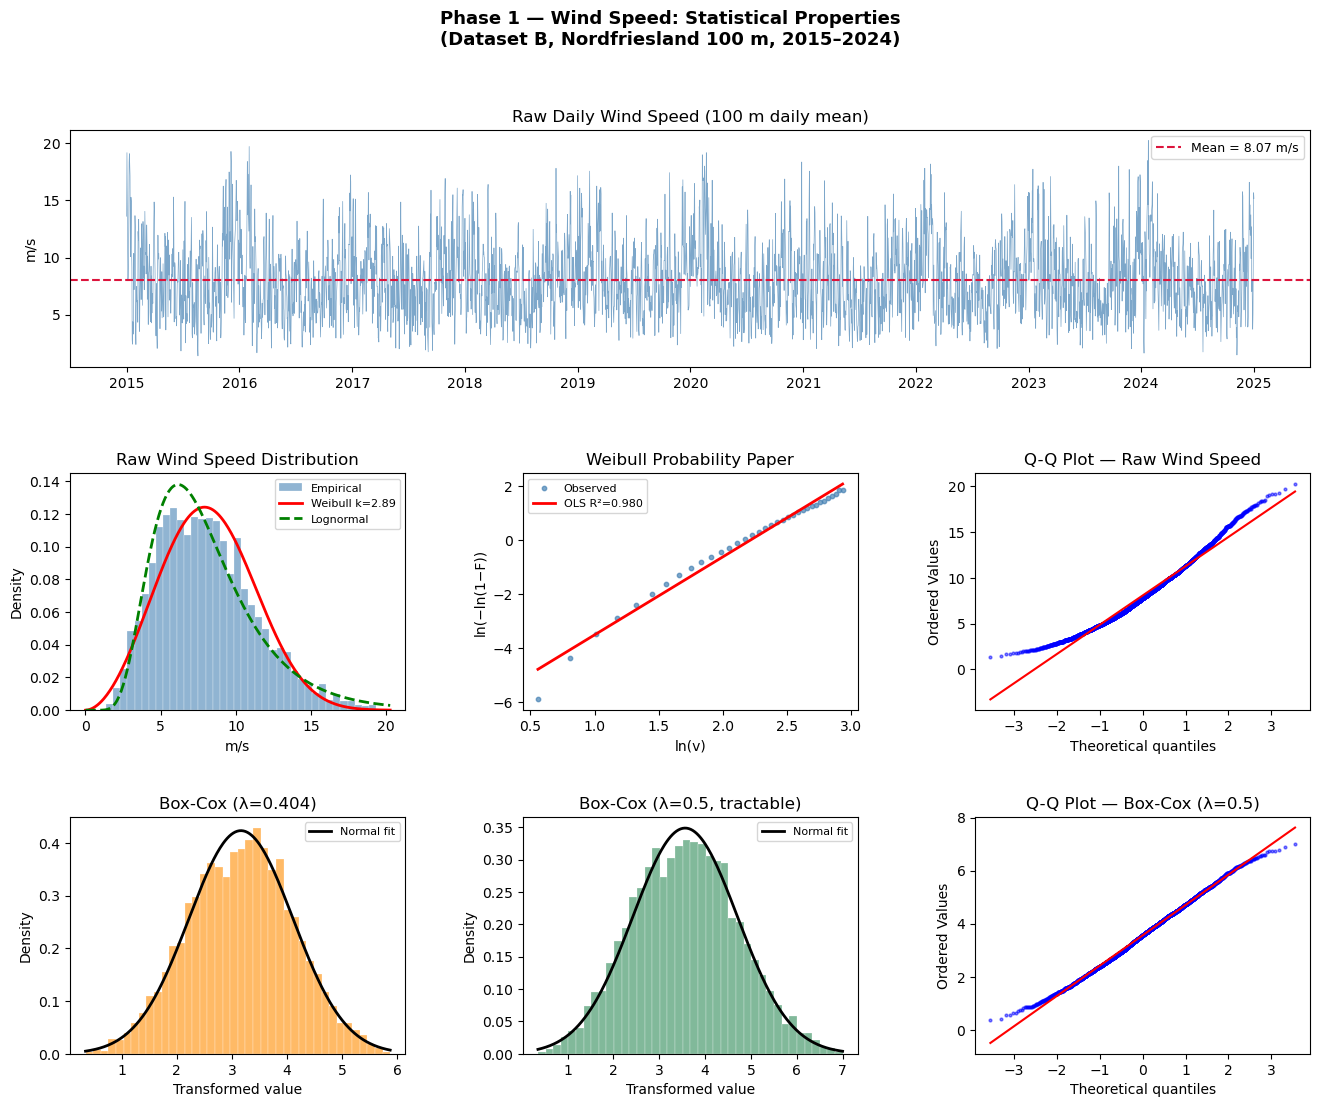

Figure saved: phase1_B_wind_analysis.png


In [36]:
fig = plt.figure(figsize=(16, 12))
fig.suptitle("Phase 1 — Wind Speed: Statistical Properties"
             "\n(Dataset B, Nordfriesland 100 m, 2015–2024)",
             fontsize=13, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

ax1 = fig.add_subplot(gs[0, :])
ax1.plot(dates, W, color='steelblue', lw=0.5, alpha=0.7)
ax1.axhline(mean_W, color='crimson', lw=1.5, ls='--', label=f'Mean = {mean_W:.2f} m/s')
ax1.set_title("Raw Daily Wind Speed (100 m daily mean)")
ax1.set_ylabel("m/s")
ax1.legend(fontsize=9)

ax2 = fig.add_subplot(gs[1, 0])
ax2.hist(W, bins=40, density=True, color='steelblue', alpha=0.6,
         edgecolor='white', lw=0.3, label='Empirical')
v_grid = np.linspace(0.01, max_W, 300)
ax2.plot(v_grid, stats.weibull_min.pdf(v_grid, k_weib, loc=0, scale=c_weib),
         'r-', lw=2, label=f'Weibull k={k_weib:.2f}')
ax2.plot(v_grid, stats.lognorm.pdf(v_grid, s=s_logn, scale=np.exp(m_logn)),
         'g--', lw=2, label='Lognormal')
ax2.set_title("Raw Wind Speed Distribution")
ax2.set_xlabel("m/s"); ax2.set_ylabel("Density"); ax2.legend(fontsize=8)

ax3 = fig.add_subplot(gs[1, 1])
ax3.scatter(t, Y, s=10, color='steelblue', alpha=0.7, label='Observed')
t_line = np.linspace(t.min(), t.max(), 100)
ax3.plot(t_line, slope * t_line + intercept, 'r-', lw=2,
         label=f'OLS R²={r2_weib_pp:.3f}')
ax3.set_title("Weibull Probability Paper")
ax3.set_xlabel("ln(v)"); ax3.set_ylabel("ln(−ln(1−F))"); ax3.legend(fontsize=8)

ax4 = fig.add_subplot(gs[1, 2])
stats.probplot(W, dist='norm', plot=ax4)
ax4.set_title("Q-Q Plot — Raw Wind Speed")
ax4.get_lines()[0].set(markersize=2, alpha=0.5)

ax5 = fig.add_subplot(gs[2, 0])
ax5.hist(W_bc_opt, bins=40, density=True, color='darkorange', alpha=0.6,
         edgecolor='white', lw=0.3)
x_grid = np.linspace(W_bc_opt.min(), W_bc_opt.max(), 300)
mu_, std_ = np.mean(W_bc_opt), np.std(W_bc_opt)
ax5.plot(x_grid, stats.norm.pdf(x_grid, mu_, std_), 'k-', lw=2, label='Normal fit')
ax5.set_title(f"Box-Cox (λ={lambda_opt:.3f})")
ax5.set_xlabel("Transformed value"); ax5.set_ylabel("Density"); ax5.legend(fontsize=8)

ax6 = fig.add_subplot(gs[2, 1])
ax6.hist(W_bc_round, bins=40, density=True, color='seagreen', alpha=0.6,
         edgecolor='white', lw=0.3)
x_grid2 = np.linspace(W_bc_round.min(), W_bc_round.max(), 300)
mu2_, std2_ = np.mean(W_bc_round), np.std(W_bc_round)
ax6.plot(x_grid2, stats.norm.pdf(x_grid2, mu2_, std2_), 'k-', lw=2, label='Normal fit')
ax6.set_title(f"Box-Cox (λ={lambda_round}, tractable)")
ax6.set_xlabel("Transformed value"); ax6.set_ylabel("Density"); ax6.legend(fontsize=8)

ax7 = fig.add_subplot(gs[2, 2])
stats.probplot(W_bc_round, dist='norm', plot=ax7)
ax7.set_title(f"Q-Q Plot — Box-Cox (λ={lambda_round})")
ax7.get_lines()[0].set(markersize=2, alpha=0.5)

plt.savefig(FIG_PATH + "phase1_B_wind_analysis.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: phase1_B_wind_analysis.png")

## 11. PLOTS — SEASONAL DECOMPOSITION & W̃(t)

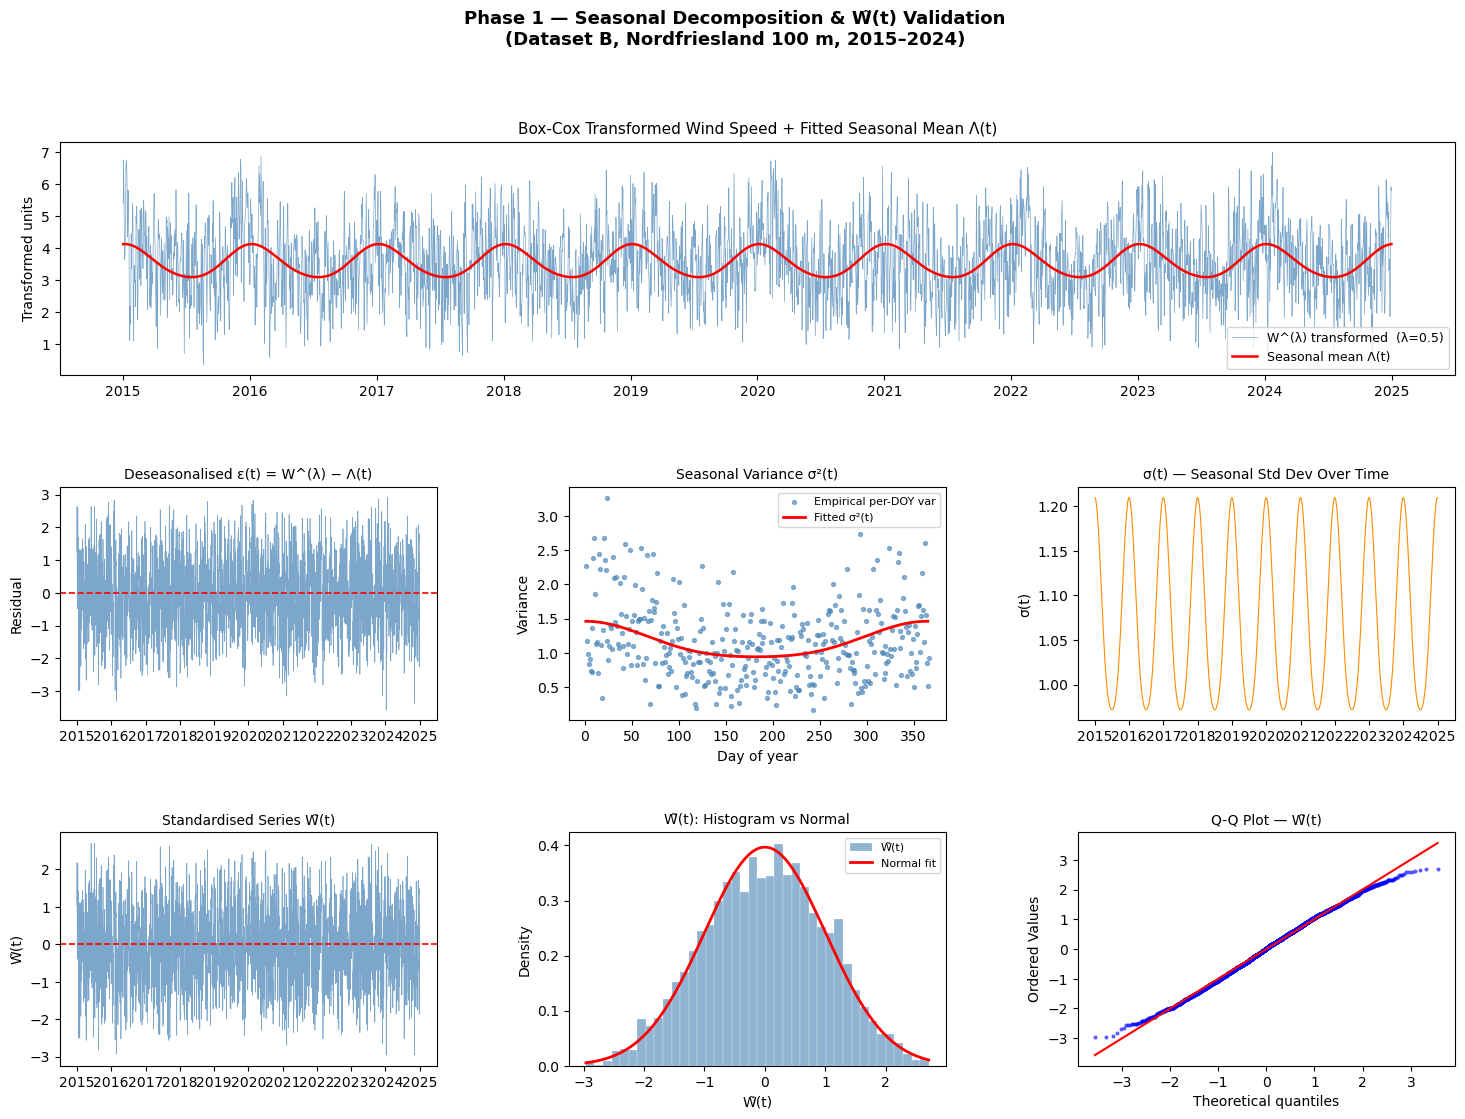

Figure saved: phase1_B_seasonal_decomposition.png


In [37]:
fig2 = plt.figure(figsize=(18, 12))
fig2.suptitle("Phase 1 — Seasonal Decomposition & W̃(t) Validation"
              "\n(Dataset B, Nordfriesland 100 m, 2015–2024)",
              fontsize=13, fontweight='bold', y=0.99)
gs2 = gridspec.GridSpec(3, 3, figure=fig2, hspace=0.48, wspace=0.35)

ax1 = fig2.add_subplot(gs2[0, :])
ax1.plot(wind_daily.index, W_bc_full, color='steelblue', lw=0.5, alpha=0.7,
         label=f'W^(λ) transformed  (λ={lambda_round})')
ax1.plot(wind_daily.index, Lambda_t, color='red', lw=1.8, label='Seasonal mean Λ(t)')
ax1.set_title("Box-Cox Transformed Wind Speed + Fitted Seasonal Mean Λ(t)", fontsize=11)
ax1.set_ylabel("Transformed units"); ax1.legend(fontsize=9)

ax2 = fig2.add_subplot(gs2[1, 0])
ax2.plot(wind_daily.index, eps_t, color='steelblue', lw=0.5, alpha=0.7)
ax2.axhline(0, color='red', lw=1.2, linestyle='--')
ax2.set_title("Deseasonalised ε(t) = W^(λ) − Λ(t)", fontsize=10)
ax2.set_ylabel("Residual")

doy_plot  = np.arange(1, 366)
sig2_plot = mod_var.predict(fourier_basis_cos(doy_plot, N_VAR_HARMONICS))

ax3 = fig2.add_subplot(gs2[1, 1])
ax3.scatter(doy_vals, emp_var_vals, s=8, color='steelblue', alpha=0.6,
            label='Empirical per-DOY var')
ax3.plot(doy_plot, sig2_plot, 'r-', lw=2, label='Fitted σ²(t)')
ax3.set_title("Seasonal Variance σ²(t)", fontsize=10)
ax3.set_xlabel("Day of year"); ax3.set_ylabel("Variance"); ax3.legend(fontsize=8)

ax4 = fig2.add_subplot(gs2[1, 2])
ax4.plot(wind_daily.index, sigma_t, color='darkorange', lw=0.8)
ax4.set_title("σ(t) — Seasonal Std Dev Over Time", fontsize=10)
ax4.set_ylabel("σ(t)")

ax5 = fig2.add_subplot(gs2[2, 0])
ax5.plot(wind_daily.index, W_tilde, color='steelblue', lw=0.5, alpha=0.7)
ax5.axhline(0, color='red', lw=1.2, linestyle='--')
ax5.set_title("Standardised Series W̃(t)", fontsize=10)
ax5.set_ylabel("W̃(t)")

ax6 = fig2.add_subplot(gs2[2, 1])
ax6.hist(W_tilde, bins=40, density=True, color='steelblue',
         alpha=0.6, edgecolor='white', lw=0.3, label='W̃(t)')
x_wt = np.linspace(W_tilde.min(), W_tilde.max(), 200)
ax6.plot(x_wt, stats.norm.pdf(x_wt, mean_wt, std_wt), 'r-', lw=2, label='Normal fit')
ax6.set_title("W̃(t): Histogram vs Normal", fontsize=10)
ax6.set_xlabel("W̃(t)"); ax6.set_ylabel("Density"); ax6.legend(fontsize=8)

ax7 = fig2.add_subplot(gs2[2, 2])
stats.probplot(W_tilde, dist='norm', plot=ax7)
ax7.set_title("Q-Q Plot — W̃(t)", fontsize=10)
ax7.get_lines()[0].set(markersize=2, alpha=0.5)

plt.savefig(FIG_PATH + "phase1_B_seasonal_decomposition.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: phase1_B_seasonal_decomposition.png")

## 12. COMPLETE PHASE 1 SUMMARY

In [38]:
print("\n" + "=" * 65)
print("  PHASE 1 — COMPLETE SUMMARY (Dataset B, Nordfriesland 100 m)")
print("=" * 65)

print(f"\n  [1] RAW WIND SPEED")
print(f"      Mean={mean_W:.3f}  Median={median_W:.3f}  Std={std_W:.3f}  m/s")
print(f"      Skew={stats.skew(W):.3f}  Kurt(P)={stats.kurtosis(W, fisher=False):.3f}")
print(f"      JB p={jb_pval:.4f}  → normality {'REJECTED' if jb_pval < 0.05 else 'NOT REJECTED'}")

print(f"\n  [2] DISTRIBUTION FIT")
print(f"      Weibull   k={k_mle:.4f}  c={c_mle:.4f}  "
      f"AIC={aic_hat_mle:.1f}  BIC={bic_hat_mle:.1f}")
print(f"      Lognormal m={m_logn:.4f}  s={s_logn:.4f}  "
      f"AIC={aic_logn:.1f}  BIC={bic_logn:.1f}")
print(f"      Better fit: {'Weibull' if aic_hat_mle < aic_logn else 'Lognormal'} (AIC & BIC)")

print(f"\n  [3] BOX-COX TRANSFORMATION")
print(f"      Optimal λ (MLE) = {lambda_opt:.4f}")
print(f"      Tractable λ     = {lambda_round}  (1/λ = {int(1/lambda_round)})")
print(f"      JB after transform: p = {jb_bc_opt[1]:.4f}  "
      f"→ {'NORMAL' if jb_bc_opt[1] > 0.05 else 'NOT NORMAL YET'}")

print(f"\n  [4] SEASONAL MEAN Λ(t)")
print(f"      Fourier harmonics: {N_HARMONICS}  |  R² = {model_mean.rsquared:.4f}")
print(f"      Mean of ε(t) = {eps_t.mean():.6f}  (≈ 0 ✓)")

print(f"\n  [5] SEASONAL VARIANCE σ²(t)")
print(f"      Fourier harmonics: {N_VAR_HARMONICS}  |  R² = {mod_var.rsquared:.4f}")
print(f"      σ(t) range: [{sigma_t.min():.4f}, {sigma_t.max():.4f}]")

print(f"\n  [6] STANDARDISED SERIES W̃(t)")
print(f"      Mean = {mean_wt:.4f}  (target 0)  |  Std = {std_wt:.4f}  (target 1)")
print(f"      Skew = {skew_wt:.4f}  |  Kurt(P) = {kurt_wt:.4f}")
print(f"      JB p = {jb_wt_p:.4f}  "
      f"{'PASS' if jb_wt_p > 0.05 else '→ autocorrelation residue, AR(4) needed'}")
print(f"      LBQ W̃   p(20) = {lb_wt['lb_pvalue'].iloc[-1]:.4f}  → AR(4) needed in Phase 2")
print(f"      LBQ W̃²  p(20) = {lb_wt2['lb_pvalue'].iloc[-1]:.4f}  → GARCH needed in Phase 3")

print(f"\n  [7] WEIBULL AEP (100 m, illustrative 3 MW turbine)")
print(f"      AEP = {aep_gwh:.4f} GWh/year  |  Capacity factor = {cap_factor*100:.2f}%")
print(f"      P(producing) = {p_above_cutin*100:.1f}%  |  "
      f"P(rated power) = {p_above_rated*100:.1f}%")

print(f"\n  PHASE 1 OUTPUT: W_tilde_series ({len(W_tilde_series)} obs)")
print(f"  Ready for Phase 2 → AR(4) / ARMA / ARFIMA modelling.")
print("=" * 65)


  PHASE 1 — COMPLETE SUMMARY (Dataset B, Nordfriesland 100 m)

  [1] RAW WIND SPEED
      Mean=8.068  Median=7.760  Std=3.236  m/s
      Skew=0.585  Kurt(P)=3.111
      JB p=0.0000  → normality REJECTED

  [2] DISTRIBUTION FIT
      Weibull   k=2.6704  c=9.0890  AIC=18758.3  BIC=18770.7
      Lognormal m=2.0022  s=0.4283  AIC=18803.1  BIC=18815.5
      Better fit: Weibull (AIC & BIC)

  [3] BOX-COX TRANSFORMATION
      Optimal λ (MLE) = 0.4039
      Tractable λ     = 0.5  (1/λ = 2)
      JB after transform: p = 0.0002  → NOT NORMAL YET

  [4] SEASONAL MEAN Λ(t)
      Fourier harmonics: 2  |  R² = 0.1031
      Mean of ε(t) = 0.000000  (≈ 0 ✓)

  [5] SEASONAL VARIANCE σ²(t)
      Fourier harmonics: 2  |  R² = 0.1158
      σ(t) range: [0.9717, 1.2095]

  [6] STANDARDISED SERIES W̃(t)
      Mean = -0.0000  (target 0)  |  Std = 1.0050  (target 1)
      Skew = -0.0570  |  Kurt(P) = 2.5779
      JB p = 0.0000  → autocorrelation residue, AR(4) needed
      LBQ W̃   p(20) = 0.0000  → AR(4) nee

## 13. SAVE PHASE 1 OUTPUT FOR PHASE 2

In [39]:
W_tilde_series.to_csv("W_tilde_phase1.csv", index=True)
print("W_tilde_phase1.csv saved")
print(f"  Shape : {W_tilde_series.shape}")
print(f"  Index : {W_tilde_series.index[0].date()} → {W_tilde_series.index[-1].date()}")

# Save Fourier variance coefficients so Phase 3 can reconstruct σ²_seasonal(t)
# without re-fitting from W̃², which would give wrong results (E[W̃²] ≈ 1)
var_coefs_df = pd.DataFrame({
    'param': ['c0', 'c1', 'c2'],
    'value': mod_var.params.tolist()
})
var_coefs_df.to_csv("variance_fourier_phase1.csv", index=False)
print("\nvariance_fourier_phase1.csv saved  (Fourier σ²(t) coefficients for Phase 3)")
print(f"  c0 = {mod_var.params[0]:.6f}")
print(f"  c1 = {mod_var.params[1]:.6f}")
print(f"  c2 = {mod_var.params[2]:.6f}")

W_tilde_phase1.csv saved
  Shape : (3653,)
  Index : 2015-01-01 → 2024-12-31

variance_fourier_phase1.csv saved  (Fourier σ²(t) coefficients for Phase 3)
  c0 = 1.162775
  c1 = 0.259329
  c2 = 0.040767
